# ***Data Cleaning***

In [32]:
import pandas as pd

# Load dataset
df = pd.read_csv("final.csv")


# 1. DATA STRUCTURE VALIDATION

print("=== Dataset Info ===")
df.info()


# 2. MISSING VALUES CHECK

print("\n=== Missing Values ===")
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print("\nNo missing values detected in the dataset.")
else:
    print("\nMissing values detected.")


# 3. DUPLICATE RECORDS CHECK

duplicates = df.duplicated().sum()

print("\n=== Duplicate Rows ===")
print("Number of duplicate rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")



# 4. SUMMARY STATISTICS

print("\n=== Summary Statistics ===")
print(df.describe())



# 5. CATEGORICAL DATA VALIDATION

print("\n=== Unique Values (Categorical Variables) ===")

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].unique())



# 6. FINAL DATASET CHECK

print("\n=== Final Dataset Shape ===")
print(df.shape)

print("\n=== Final Missing Values ===")
print(df.isnull().sum())

print("\nData cleaning completed successfully.")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 34 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Month                 150000 non-null  int64  
 1   WeekOfMonth           150000 non-null  int64  
 2   DayOfWeek             150000 non-null  int64  
 3   Make                  150000 non-null  object 
 4   AccidentArea          150000 non-null  object 
 5   DayOfWeekClaimed      150000 non-null  int64  
 6   MonthClaimed          150000 non-null  int64  
 7   WeekOfMonthClaimed    150000 non-null  int64  
 8   Sex                   150000 non-null  object 
 9   MaritalStatus         150000 non-null  object 
 10  Age                   150000 non-null  int64  
 11  Fault                 150000 non-null  object 
 12  PolicyType            150000 non-null  object 
 13  VehicleCategory       150000 non-null  object 
 14  VehiclePrice          150000 no

# ***Treating the Categorical Variables***

In [33]:
import pandas as pd

# 1. BINARY ENCODING (TARGET VARIABLE)

# Convert FraudFound into binary format (0 = No, 1 = Yes)
df['FraudFound'] = df['FraudFound'].map({'No': 0, 'Yes': 1})

print("=== Binary Encoding Applied ===")
print(df['FraudFound'].head())


# 2. IDENTIFY CATEGORICAL VARIABLES

# Select categorical columns (excluding target)
categorical_cols = df.select_dtypes(include=['object']).columns

print("\n=== Categorical Variables ===")
print(categorical_cols)


# 3. ONE-HOT ENCODING (FOR FEATURES)

# Apply One-Hot Encoding to categorical features only
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\n=== One-Hot Encoding Applied ===")
print(df_encoded.head())


# 4. REMOVE IRRELEVANT COLUMNS (IDs)

# Drop ID-like columns that do not help models
df_encoded = df_encoded.drop(columns=['PolicyNumber', 'RepNumber'], errors='ignore')


# 5. FINAL CHECK

print("\n=== Data Types After Encoding ===")
print(df_encoded.dtypes)

print("\n=== Final Dataset Shape ===")
print(df_encoded.shape)

print("\nCategorical variable treatment completed successfully.")

=== Binary Encoding Applied ===
0    1
1    0
2    0
3    0
4    1
Name: FraudFound, dtype: int64

=== Categorical Variables ===
Index(['Make', 'AccidentArea', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType',
       'VehicleCategory', 'Days:Policy-Accident', 'Days:Policy-Claim',
       'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'AddressChange-Claim', 'BasePolicy'],
      dtype='object')

=== One-Hot Encoding Applied ===
   Month  WeekOfMonth  DayOfWeek  DayOfWeekClaimed  MonthClaimed  \
0     11            1          3                 7            12   
1      2            3          7                 1             7   
2     10            1          3                 5            12   
3     11            3          2                 5             8   
4      6            1          5                 7             2   

   WeekOfMonthClaimed  Age  VehiclePrice  ClaimAmount  PolicyNumber  ...  \
0                   4   43  6.308436e+05      20000.0        121959  ...   
1

# ***Splitting the Dataset***

In [34]:
# Import required library
from sklearn.model_selection import train_test_split

# 1. DEFINE FEATURES AND TARGET (REGRESSION)

# Features (independent variables)
X = df_encoded.drop(['VehiclePrice'], axis=1)

# Target variable (dependent variable)
y = df_encoded['VehiclePrice']


# 2. SPLIT DATASET

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% testing data
    random_state=42     # Ensures reproducibility
)


# 3. DISPLAY RESULTS

print("=== Dataset Split Summary ===")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

=== Dataset Split Summary ===
X_train shape: (120000, 40)
X_test shape: (30000, 40)
y_train shape: (120000,)
y_test shape: (30000,)


# ***Feature Scaling***

In [35]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Copy data to avoid overwriting
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Select ONLY numerical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Initialize scaler
scaler = StandardScaler()

# Apply scaling to numerical columns only
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("=== Feature Scaling Applied (Numerical Only) ===")
print(X_train_scaled.head())

=== Feature Scaling Applied (Numerical Only) ===
           Month  WeekOfMonth  DayOfWeek  DayOfWeekClaimed  MonthClaimed  \
104025 -1.300955    -0.450415  -0.998651         -1.495961      1.015556   
5415    1.596092     1.339521   1.001618          0.001985     -1.301153   
75612   0.726978    -1.345383   0.001484          1.499931     -0.721976   
138169  1.306387    -1.345383  -0.498584          0.001985      0.146790   
87184  -0.142136    -0.450415  -1.498718          0.001985      1.305144   

        WeekOfMonthClaimed       Age  ClaimAmount  Deductible  DriverRating  \
104025           -0.448252  0.314469          0.0   -0.995759     -1.407349   
5415              0.447580 -1.350537          0.0   -0.995759     -0.700771   
75612            -1.344084 -0.240533          0.0    1.004259      1.418960   
138169           -1.344084  1.285723          0.0   -0.995759      0.005806   
87184             1.343412 -0.032407          0.0    1.004259      0.005806   

        ...  Vehicl

# ***Regression Models:***

# ***1. Multiple Linear Regression***

In [36]:
# Import required libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
mlr = LinearRegression()

# Train the model using training data
mlr.fit(X_train, y_train)

# Predict VehiclePrice using test data
y_pred_mlr = mlr.predict(X_test)

# Calculate evaluation metrics
mse_mlr = mean_squared_error(y_test, y_pred_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)

# Print results
print("Multiple Linear Regression Results:")
print("Mean Squared Error (MSE):", mse_mlr)
print("R-squared (R²):", r2_mlr)

Multiple Linear Regression Results:
Mean Squared Error (MSE): 42883272168.045166
R-squared (R²): 0.5149438639245315


# ***2. Polynomial Regression***

In [37]:
# Import required library for polynomial features
from sklearn.preprocessing import PolynomialFeatures

# Transform features into polynomial features (degree = 2)
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

# Train Linear Regression on transformed features
poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

# Predict using polynomial model
y_pred_poly = poly_model.predict(X_poly_test)

# Evaluate model
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

# Print results
print("Polynomial Regression Results:")
print("Mean Squared Error (MSE):", mse_poly)
print("R-squared (R²):", r2_poly)

Polynomial Regression Results:
Mean Squared Error (MSE): 42393189381.97431
R-squared (R²): 0.5204872296834945


# ***3. Ridge Regression***

In [38]:
# Import Ridge Regression model
from sklearn.linear_model import Ridge

# Initialize Ridge model with regularization parameter alpha
ridge = Ridge(alpha=1.0)

# Train model
ridge.fit(X_train, y_train)

# Predict results
y_pred_ridge = ridge.predict(X_test)

# Evaluate performance
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Print results
print("Ridge Regression Results:")
print("Mean Squared Error (MSE):", mse_ridge)
print("R-squared (R²):", r2_ridge)

Ridge Regression Results:
Mean Squared Error (MSE): 42883268403.52365
R-squared (R²): 0.5149439065053367


# ***4. Lasso Regression***

In [39]:
# Import Lasso Regression model
from sklearn.linear_model import Lasso

# Initialize Lasso model (L1 regularization)
lasso = Lasso(alpha=0.1)

# Train model
lasso.fit(X_train, y_train)

# Predict results
y_pred_lasso = lasso.predict(X_test)

# Evaluate model
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

# Print results
print("Lasso Regression Results:")
print("Mean Squared Error (MSE):", mse_lasso)
print("R-squared (R²):", r2_lasso)

Lasso Regression Results:
Mean Squared Error (MSE): 42883265890.21802
R-squared (R²): 0.5149439349335387


# ***5. Elastic Net Regression***

In [40]:
# Import Elastic Net model
from sklearn.linear_model import ElasticNet

# Initialize Elastic Net (combines L1 and L2 regularization)
enet = ElasticNet(alpha=0.1)

# Train model
enet.fit(X_train, y_train)

# Predict results
y_pred_enet = enet.predict(X_test)

# Evaluate model
mse_enet = mean_squared_error(y_test, y_pred_enet)
r2_enet = r2_score(y_test, y_pred_enet)

# Print results
print("Elastic Net Regression Results:")
print("Mean Squared Error (MSE):", mse_enet)
print("R-squared (R²):", r2_enet)

Elastic Net Regression Results:
Mean Squared Error (MSE): 46261629246.829605
R-squared (R²): 0.47673099564113885


# ***6. Decision Tree Regressor(Extra model)***

In [41]:
# Import Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

# Initialize model
dt = DecisionTreeRegressor(random_state=42)

# Train model
dt.fit(X_train, y_train)

# Predict results
y_pred_dt = dt.predict(X_test)

# Evaluate model
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# Print results
print("Decision Tree Results:")
print("Mean Squared Error (MSE):", mse_dt)
print("R-squared (R²):", r2_dt)

Decision Tree Results:
Mean Squared Error (MSE): 85336710726.90097
R-squared (R²): 0.03474961032882695


# ***7. Random Forest Regressor(Extra model)***

In [42]:
# Import Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Initialize model with multiple trees
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf.fit(X_train, y_train)

# Predict results
y_pred_rf = rf.predict(X_test)

# Evaluate model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Print results
print("Random Forest Results:")
print("Mean Squared Error (MSE):", mse_rf)
print("R-squared (R²):", r2_rf)

Random Forest Results:
Mean Squared Error (MSE): 42891609508.211174
R-squared (R²): 0.51484955960022


In [43]:
## Extract Equation (Linear Regression) ##

print(mlr.intercept_)
print(mlr.coef_)

935224.9816571572
[ 7.68645877e+01  1.01405176e+02 -2.73541255e+02 -6.48924098e+01
  2.55470718e+02 -1.18024150e+03  2.10821344e+01 -1.35623850e-08
 -4.54055095e+00 -3.69804424e+02  4.09943198e+02  4.51621717e+01
 -8.83885346e+01  1.04724473e+01  4.67918024e+02 -4.08123315e+01
  1.21651075e+03  4.87194401e+04  4.79426782e+04  1.46013196e+04
  4.81173614e+04  1.22835143e+03 -1.12858129e+03  1.81773534e+03
  3.98219477e+03  3.48319185e+03 -1.39867701e+03  7.20139369e+02
 -1.47967586e+03  5.19359389e+05  2.38908464e+05  7.24383470e+02
 -7.42982150e+02  1.87885269e+02 -2.19731911e+03 -7.45426928e+02
  5.37055700e+02 -1.57475179e+03  3.35124470e+02 -1.32335728e+03]


# ***Visualization: Observed vs Predicted Values***

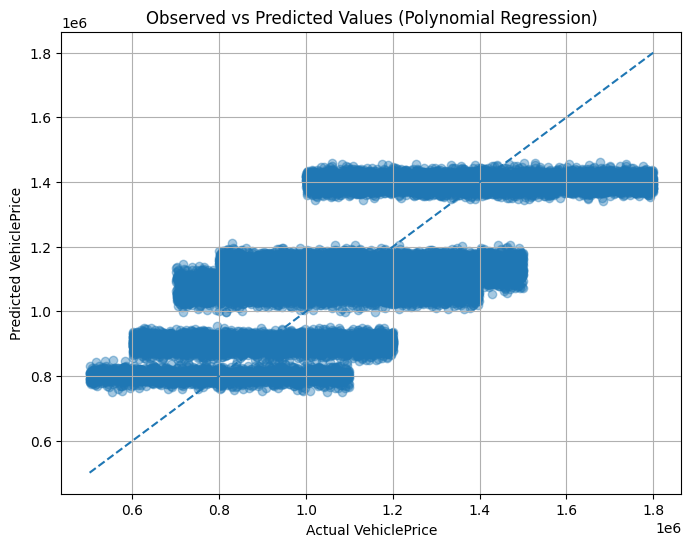

In [44]:
# VISUALIZATION: ACTUAL vs PREDICTED VALUES
# (Polynomial Regression)

import matplotlib.pyplot as plt

# 1. Create scatter plot
# Each point = one data sample
# X-axis = actual values
# Y-axis = predicted values

plt.figure(figsize=(8,6))  # optional: better size

plt.scatter(
    y_test,            # actual values
    y_pred_poly,       # predicted values
    alpha=0.4          # transparency for better visibility
)

# 2. Add perfect prediction line (diagonal)

# This line represents ideal predictions (y = x)

min_val = min(y_test.min(), y_pred_poly.min())
max_val = max(y_test.max(), y_pred_poly.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'   # dashed line
)

# 3. Labels and title
plt.xlabel("Actual VehiclePrice")
plt.ylabel("Predicted VehiclePrice")
plt.title("Observed vs Predicted Values (Polynomial Regression)")

# 4. Add grid for readability

plt.grid()

# 5. Show plot
plt.show()

jjjjjjjjjjjjjjjj

In [45]:
# VERIFY MANUAL CALCULATION (5 RECORDS)

import pandas as pd

# Step 1: Select the SAME 5 records (original data BEFORE encoding/scaling)
sample_data = df.iloc[:5].copy()

# Step 2: Extract only the variables used in your manual equation
X_manual = sample_data[['Month', 'WeekOfMonth', 'DayOfWeek', 'Age', 'Deductible']]

# Step 3: Define coefficients (from your model)
intercept = 935224.98

b1 = 76.86      # Month
b2 = 101.41     # WeekOfMonth
b3 = -273.54    # DayOfWeek
b4 = 10.47      # Age
b5 = -88.39     # Deductible

# Step 4: Apply manual equation in Python
y_manual = (
    intercept
    + b1 * X_manual['Month']
    + b2 * X_manual['WeekOfMonth']
    + b3 * X_manual['DayOfWeek']
    + b4 * X_manual['Age']
    + b5 * X_manual['Deductible']
)

# Step 5: Compare with actual values
results = pd.DataFrame({
    "Actual VehiclePrice": sample_data['VehiclePrice'],
    "Predicted (Manual Equation)": y_manual
})

# Round for clean comparison
results = results.round(2)

print(results)

   Actual VehiclePrice  Predicted (Manual Equation)
0            630843.62                    900445.44
1           1243086.13                    898778.60
2           1206393.28                    908966.77
3           1291825.09                    909499.05
4            712365.05                    908489.17


# ***1. Logistic Regression***

In [46]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Preparing dataset
X = df_encoded.drop('FraudFound', axis=1).values
y = df_encoded['FraudFound'].values

# Splitting the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the model
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

# Evaluation
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
y_pred = classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

[[21005     0]
 [ 8995     0]]
Accuracy: 0.7001666666666667
Precision: 0.0
Recall: 0.0
F1-score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# ***2. K-Nearest Neighbours (KNN)***

In [47]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

[[17511  3494]
 [ 7528  1467]]
Accuracy: 0.6326
Precision: 0.2957065107841161
Recall: 0.16309060589216232
F1-score: 0.2102321582115219


# ***3. Support Vector Machine (SVM)***

In [48]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Use subset (faster than full dataset)
X_train_sample = X_train[:10000]
y_train_sample = y_train[:10000]

# Train SVM model

classifier = SVC(kernel='rbf')
classifier.fit(X_train_sample, y_train_sample)


# Predict

y_pred = classifier.predict(X_test)

# Evaluate

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[21005     0]
 [ 8995     0]]

Accuracy: 0.7001666666666667
Precision: 0.0
Recall: 0.0
F1-score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# ***4. Decision Tree***

In [49]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(criterion='entropy', random_state=42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

[[14381  6624]
 [ 6126  2869]]
Accuracy: 0.575
Precision: 0.3022226904034552
Recall: 0.31895497498610337
F1-score: 0.3103634790134141


# ***5. Random Forest***

In [50]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

[[20999     6]
 [ 8992     3]]
Accuracy: 0.7000666666666666
Precision: 0.3333333333333333
Recall: 0.00033351862145636465
F1-score: 0.0006663705019991116


# ***6. Gradient Boosting (Extra Model)***

In [51]:
from sklearn.ensemble import GradientBoostingClassifier

classifier = GradientBoostingClassifier()
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

[[21002     3]
 [ 8994     1]]
Accuracy: 0.7001
Precision: 0.25
Recall: 0.00011117287381878821
F1-score: 0.00022224691632403602


# ***7. XGBoost (Extra Model)***

In [52]:
from xgboost import XGBClassifier

classifier = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:49:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[[20737   268]
 [ 8862   133]]
Accuracy: 0.6956666666666667
Precision: 0.3316708229426434
Recall: 0.014785992217898832
F1-score: 0.028309919114516816


In [53]:
# FIX + COUNT CLASS DISTRIBUTION

# Step 1: Use your best model predictions
y_pred_best = y_pred_dt
# Step 2: Convert predictions to binary (0 or 1)

# This ensures even if values are weird, we fix them

y_pred_best = (y_pred_best > 0.5).astype(int)

# Step 3: Count values
# --------------------

num_non_fraud = 0
num_fraud = 0

for val in y_pred_best:
    if val == 0:
        num_non_fraud += 1
    elif val == 1:
        num_fraud += 1

# Step 4: Print clean result


print("\n=== Class Distribution (Predicted) ===")
print("Number of Non-Fraud (0):", num_non_fraud)
print("Number of Fraud (1):", num_fraud)


=== Class Distribution (Predicted) ===
Number of Non-Fraud (0): 0
Number of Fraud (1): 30000
